# 07 KNN Fraud Detection Model

This notebook trains a K-Nearest Neighbors classifier for fraud detection. It follows the same overall workflow as the other model notebooks so the result can be compared as an additional supervised model.


## Model Plan

- **Model:** K-Nearest Neighbors (KNN)
- **Learning type:** Supervised classification
- **Target:** `is_fraud`
- **Reason for model choice:** KNN is a simple distance-based model that predicts fraud by comparing a transaction with similar historical transactions.
- **Important limitation:** KNN can be slow on large datasets because prediction requires distance comparisons with many training rows. For efficiency, this notebook uses a smaller stratified sample than the tree-based models.


In [1]:
from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

PROJECT_ROOT = Path("..").resolve()
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "cleaned_transactions.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR = PROJECT_ROOT / "models"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE = 100_000


## Load Cleaned Data


In [2]:
use_columns = [
    "id", "date", "amount", "use_chip", "merchant_state", "mcc", "errors", "is_fraud"
]

transactions = pd.read_csv(DATA_FILE, usecols=use_columns)
transactions.shape


(8914963, 8)

In [3]:
transactions["is_fraud"].value_counts(normalize=True).mul(100).round(4).rename("percent")


is_fraud
0    99.8505
1     0.1495
Name: percent, dtype: float64

## Feature Engineering

The same feature set is used as the other model notebooks. Numeric features are scaled later because KNN depends on distance.


In [4]:
model_data = transactions.copy()

model_data["date"] = pd.to_datetime(model_data["date"], errors="coerce")
model_data["amount_value"] = pd.to_numeric(
    model_data["amount"].astype(str).str.replace("$", "", regex=False),
    errors="coerce",
)
model_data["abs_amount"] = model_data["amount_value"].abs()
model_data["is_negative_amount"] = (model_data["amount_value"] < 0).astype(int)
model_data["hour"] = model_data["date"].dt.hour
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["month"] = model_data["date"].dt.month
model_data["has_error"] = model_data["errors"].notna().astype(int)
model_data["merchant_state"] = model_data["merchant_state"].fillna("Unknown")
model_data["use_chip"] = model_data["use_chip"].fillna("Unknown")
model_data["mcc"] = model_data["mcc"].astype(str)

feature_columns = [
    "abs_amount",
    "is_negative_amount",
    "hour",
    "day_of_week",
    "month",
    "use_chip",
    "merchant_state",
    "mcc",
    "has_error",
]

model_data = model_data.dropna(subset=feature_columns + ["is_fraud"])
X = model_data[feature_columns]
y = model_data["is_fraud"].astype(int)

pd.DataFrame({"feature": feature_columns})


,feature
0,abs_amount
1,is_negative_amount
2,hour
3,day_of_week
4,month
5,use_chip
6,merchant_state
7,mcc
8,has_error


## Optional Stratified Sampling

KNN is slower during prediction because it compares test rows to stored training rows. A 100,000-row stratified sample is used to keep the notebook practical while preserving the fraud/non-fraud ratio.


In [5]:
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(X):
    sampled, _ = train_test_split(
        model_data,
        train_size=SAMPLE_SIZE,
        stratify=model_data["is_fraud"],
        random_state=RANDOM_STATE,
    )
    X = sampled[feature_columns]
    y = sampled["is_fraud"].astype(int)

pd.DataFrame(
    {
        "rows_used": [len(X)],
        "fraud_count": [int(y.sum())],
        "fraud_rate_percent": [round(y.mean() * 100, 4)],
    }
)


,rows_used,fraud_count,fraud_rate_percent
0,100000,150,0.15


## Train-Test Split


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "fraud_count": [int(y_train.sum()), int(y_test.sum())],
        "fraud_rate_percent": [round(y_train.mean() * 100, 4), round(y_test.mean() * 100, 4)],
    }
)


,dataset,rows,fraud_count,fraud_rate_percent
0,train,75000,113,0.1507
1,test,25000,37,0.1480


## Build KNN Pipeline

The pipeline imputes missing values, scales numeric features, one-hot encodes categorical features, and trains KNN. Distance weighting gives closer neighbors more influence.


In [7]:
numeric_features = ["abs_amount", "is_negative_amount", "hour", "day_of_week", "month", "has_error"]
categorical_features = ["use_chip", "merchant_state", "mcc"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance",
    metric="minkowski",
    n_jobs=-1,
)

knn_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", knn_model),
    ]
)
print("KNN pipeline created.")


KNN pipeline created.


## Train Model


In [8]:
start_time = time.perf_counter()
knn_pipeline.fit(X_train, y_train)
print("KNN model trained.")
training_time_seconds = time.perf_counter() - start_time
round(training_time_seconds, 2)


KNN model trained.


0.13

## Complexity and Efficiency Notes

KNN has very fast training because it mainly stores the training data. However, prediction is expensive because each test transaction must be compared against many training transactions. This makes KNN less suitable for very large fraud datasets compared with Random Forest.


In [9]:
encoded_feature_count = len(knn_pipeline.named_steps["preprocess"].get_feature_names_out())
complexity_summary = pd.DataFrame(
    {
        "item": [
            "training rows",
            "test rows",
            "input features before encoding",
            "features after one-hot encoding",
            "number of neighbors",
            "weighting method",
            "training time seconds",
        ],
        "value": [
            len(X_train),
            len(X_test),
            len(feature_columns),
            encoded_feature_count,
            knn_pipeline.named_steps["model"].n_neighbors,
            knn_pipeline.named_steps["model"].weights,
            round(training_time_seconds, 2),
        ],
    }
)
complexity_summary


,item,value
0,training rows,75000
1,test rows,25000
2,input features before encoding,9
3,features after one-hot encoding,228
4,number of neighbors,5
5,weighting method,distance
6,training time seconds,0.13


## Evaluate Model


In [10]:
start_time = time.perf_counter()
y_pred = knn_pipeline.predict(X_test)
y_score = knn_pipeline.predict_proba(X_test)[:, 1]
prediction_time_seconds = time.perf_counter() - start_time

metrics_summary = pd.DataFrame(
    {
        "model": ["KNN"],
        "accuracy": [accuracy_score(y_test, y_pred)],
        "roc_auc": [roc_auc_score(y_test, y_score)],
        "pr_auc": [average_precision_score(y_test, y_score)],
        "training_time_seconds": [training_time_seconds],
        "prediction_time_seconds": [prediction_time_seconds],
    }
)
metrics_summary.round(4)


,model,accuracy,roc_auc,pr_auc,training_time_seconds,prediction_time_seconds
0,KNN,0.9986,0.6884,0.2195,0.1338,10.264


In [11]:
print(classification_report(y_test, y_pred, target_names=["Non-fraud", "Fraud"], digits=4))


              precision    recall  f1-score   support

   Non-fraud     0.9986    1.0000    0.9993     24963
       Fraud     0.6667    0.0541    0.1000        37

    accuracy                         0.9986     25000
   macro avg     0.8326    0.5270    0.5496     25000
weighted avg     0.9981    0.9986    0.9979     25000



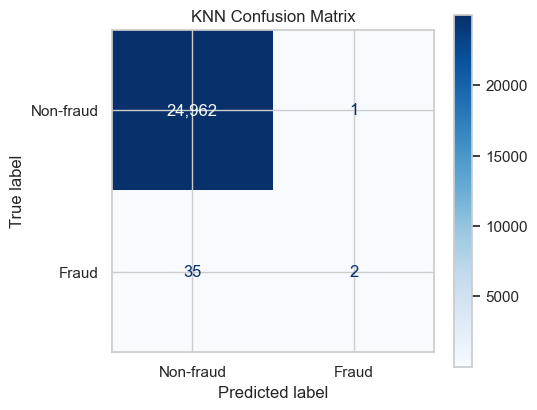

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-fraud", "Fraud"],
    cmap="Blues",
    values_format=",d",
    ax=ax,
)
ax.set_title("KNN Confusion Matrix")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_knn_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()


## Threshold Review


In [13]:
threshold_rows = []
for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:
    threshold_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    threshold_rows.append(
        {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "false_positives": fp,
            "false_negatives": fn,
        }
    )

threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary.round(4)


,threshold,precision,recall,f1,false_positives,false_negatives
0,0.1,0.2154,0.3784,0.2745,51,23
1,0.2,0.4000,0.3243,0.3582,18,25
2,0.3,0.4167,0.1351,0.2041,7,32
3,0.4,0.6667,0.1081,0.1860,2,33
4,0.5,0.6667,0.0541,0.1000,1,35


## KNN Threshold Trade-Off Graph


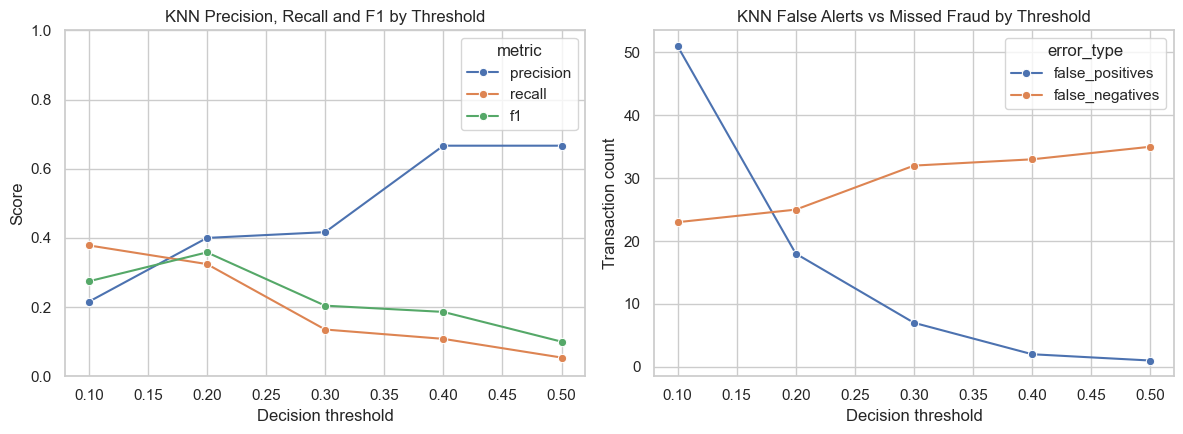

In [14]:
threshold_plot = threshold_summary.melt(
    id_vars="threshold",
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.lineplot(data=threshold_plot, x="threshold", y="score", hue="metric", marker="o", ax=axes[0])
axes[0].set_title("KNN Precision, Recall and F1 by Threshold")
axes[0].set_xlabel("Decision threshold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)

error_plot = threshold_summary.melt(
    id_vars="threshold",
    value_vars=["false_positives", "false_negatives"],
    var_name="error_type",
    value_name="count",
)
sns.lineplot(data=error_plot, x="threshold", y="count", hue="error_type", marker="o", ax=axes[1])
axes[1].set_title("KNN False Alerts vs Missed Fraud by Threshold")
axes[1].set_xlabel("Decision threshold")
axes[1].set_ylabel("Transaction count")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_knn_threshold_tradeoff.png", dpi=160, bbox_inches="tight")
plt.show()


## Precision-Recall Curve


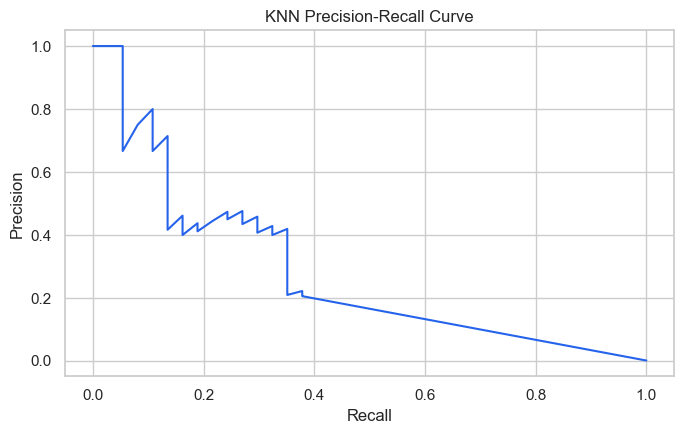

In [15]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recall, precision, color="#2563eb")
ax.set_title("KNN Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_knn_precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()


## ROC Curve


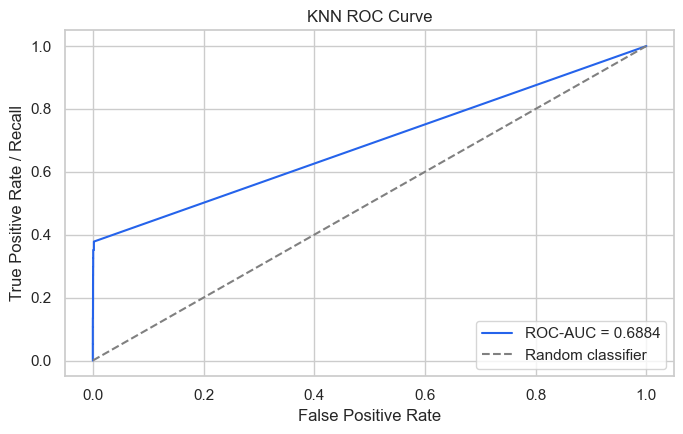

In [16]:
false_positive_rate, true_positive_rate, roc_thresholds = roc_curve(y_test, y_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(false_positive_rate, true_positive_rate, color="#2563eb", label=f"ROC-AUC = {roc_auc_score(y_test, y_score):.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
ax.set_title("KNN ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Recall")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_knn_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()


## Save Model


In [17]:
model_path = MODEL_DIR / "knn_fraud_model.joblib"
joblib.dump(knn_pipeline, model_path)
model_path


PosixPath('/Users/zichen/Big-Data-Project/models/knn_fraud_model.joblib')

## Report Notes

1. KNN was added as a distance-based supervised comparison model.
2. It uses a smaller stratified sample because KNN prediction is expensive on large datasets.
3. KNN is easy to understand, but it is less scalable than Random Forest for large fraud detection datasets.
4. Random Forest can be selected as the final model because it gives strong fraud recall, feature importance, and better scalability than KNN.
